# 🔬 XAI en Imagerie Médicale : ViT vs CNN

## Notebook de Démonstration

Ce notebook présente une démonstration complète de:
1. Chargement et préparation du dataset ISIC
2. Comparaison CNN (ResNet) vs ViT
3. Application des méthodes XAI
4. Évaluation et visualisation des explications

---

## 1. Installation et Imports

In [ ]:
# Installation des dépendances (si nécessaire)
#!pip install torch torchvision timm pytorch-grad-cam captum shap lime albumentations

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Ajouter le path du projet
sys.path.append('..')

Device: cpu


## 2. Chargement du Dataset ISIC

In [2]:
# Imports locaux
from data.isic_dataset import ISICDataset, get_data_loaders, download_isic_instructions
from models.architectures import ModelFactory

# Configuration du dataset
DATA_DIR = '../data/ISIC2019'  # Ajuster selon votre configuration

# Vérifier si le dataset existe
if not os.path.exists(DATA_DIR):
    print("⚠️ Dataset ISIC non trouvé!")
    download_isic_instructions()
else:
    print("✓ Dataset trouvé")

✓ Dataset trouvé


In [3]:
# Charger les données (si disponibles)
try:
    loaders = get_data_loaders(
        root_dir=DATA_DIR,
        batch_size=32,
        image_size=224,
        num_workers=4
    )
    
    print(f"Train: {len(loaders['train'].dataset)} images")
    print(f"Val: {len(loaders['val'].dataset)} images")
    print(f"Test: {len(loaders['test'].dataset)} images")
    print(f"\nClasses: {ISICDataset.CLASS_NAMES}")
except FileNotFoundError:
    print("Dataset non disponible - utilisation de données synthétiques pour la démo")
    loaders = None

Train: 20264 images
Val: 2533 images
Test: 2534 images

Classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


d:\Bureau\mythese\xai_medical_imaging\notebooks\..\data\isic_dataset.py:134: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


## 3. Visualisation d'Échantillons

C:\Users\youssef\AppData\Roaming\Python\Python39\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


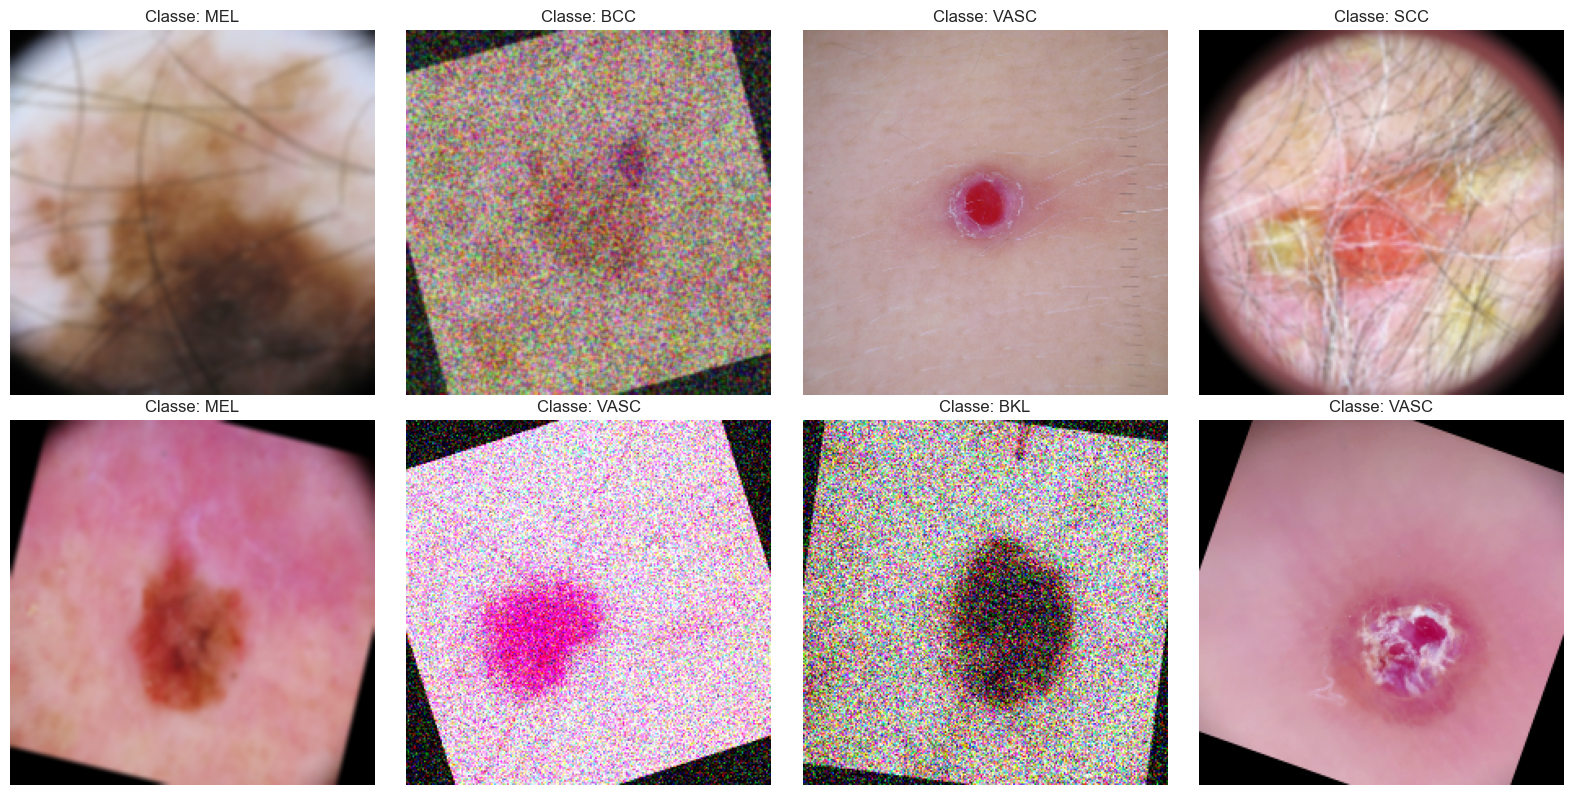

In [4]:
def visualize_samples(dataloader, num_samples=8):
    """Visualiser des échantillons du dataset."""
    images, labels, _ = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for idx, ax in enumerate(axes.flat):
        if idx >= num_samples:
            break
        
        img = images[idx] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_title(f"Classe: {ISICDataset.CLASS_NAMES[labels[idx]]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

if loaders:
    visualize_samples(loaders['train'])

## 4. Création des Modèles

In [5]:
# Créer les modèles
NUM_CLASSES = 9  # ISIC 2019

# CNN: ResNet-50
print("Chargement de ResNet-50...")
resnet = ModelFactory.create('resnet50', num_classes=NUM_CLASSES, pretrained=True)
resnet = resnet.to(device)
resnet.eval()
print(f"  ✓ Type: {resnet.model_type}")

# ViT: ViT-Base
print("\nChargement de ViT-Base...")
vit = ModelFactory.create('vit_base', num_classes=NUM_CLASSES, pretrained=True)
vit = vit.to(device)
vit.eval()
print(f"  ✓ Type: {vit.model_type}")

Chargement de ResNet-50...
  ✓ Type: cnn

Chargement de ViT-Base...
  ✓ Type: vit


In [6]:
# Afficher les modèles disponibles
print("\nModèles disponibles:")
print("-" * 30)
for name, model_type in ModelFactory.list_models().items():
    print(f"  • {name}: {model_type}")


Modèles disponibles:
------------------------------
  • resnet50: cnn
  • efficientnet_b4: cnn
  • vit_base: vit
  • deit_base: vit
  • swin_base: vit
  • convnext_base: hybrid


## 5. Application des Méthodes XAI

In [10]:
from pytorch_grad_cam import GradCAM

layer = resnet.get_target_layer()

print("Layer:", layer)

cam = GradCAM(model=resnet, target_layers=[layer])


Layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop_block): Identity()
  (act2): ReLU(inplace=True)
  (aa): Identity()
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act3): ReLU(inplace=True)
)


In [8]:
print("ResNet target:", resnet.get_target_layer())
print("ViT target:", vit.get_target_layer())

ResNet target: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop_block): Identity()
  (act2): ReLU(inplace=True)
  (aa): Identity()
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act3): ReLU(inplace=True)
)
ViT target: LayerNorm((768,), eps=1e-06, elementwise_affine=True)


In [11]:
from xai_methods.explainers import (
    GradCAMExplainer, 
    AttentionRolloutExplainer,
    IntegratedGradientsExplainer,
    XAIFactory
)

print("Initialisation des méthodes XAI...")

# Grad-CAM pour ResNet
gradcam_resnet = GradCAMExplainer(
    resnet, 
    resnet.get_target_layer(), 
    device
)
print("  ✓ Grad-CAM (ResNet)")

# Grad-CAM pour ViT
gradcam_vit = GradCAMExplainer(
    vit,
    vit.get_target_layer(),
    device
)
print("  ✓ Grad-CAM (ViT)")

# Attention Rollout pour ViT
attention_rollout = AttentionRolloutExplainer(vit, device)
print("  ✓ Attention Rollout (ViT)")

# Integrated Gradients
ig_resnet = IntegratedGradientsExplainer(resnet, device, n_steps=50)
ig_vit = IntegratedGradientsExplainer(vit, device, n_steps=50)
print("  ✓ Integrated Gradients")

Exception ignored in: <function BaseCAM.__del__ at 0x00000205CFD2EDC0>
Traceback (most recent call last):
  File "d:\Program_Files\anaconda3\envs\opencv\lib\site-packages\pytorch_grad_cam\base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'


Initialisation des méthodes XAI...


TypeError: __init__() got an unexpected keyword argument 'use_cuda'

## 6. Démonstration avec une Image Synthétique

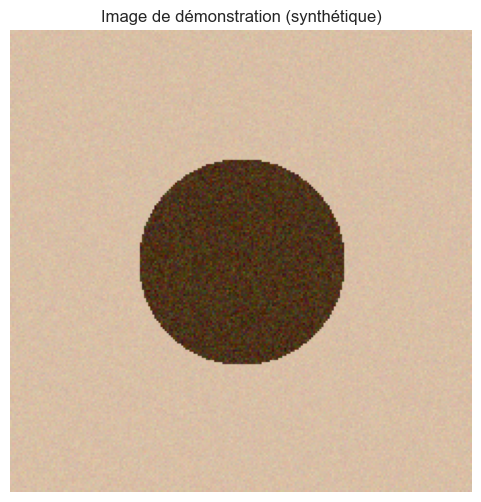

In [8]:
# Créer une image synthétique pour la démo
def create_demo_image():
    """Créer une image synthétique ressemblant à une lésion cutanée."""
    np.random.seed(42)
    
    # Fond de peau
    img = np.ones((224, 224, 3)) * np.array([0.85, 0.75, 0.65])
    
    # Ajouter une "lésion" circulaire
    y, x = np.ogrid[:224, :224]
    center_x, center_y = 112, 112
    radius = 50
    mask = ((x - center_x)**2 + (y - center_y)**2) < radius**2
    
    # Colorer la lésion (brun foncé avec variations)
    lesion_color = np.array([0.3, 0.2, 0.1])
    img[mask] = lesion_color + np.random.randn(np.sum(mask), 3) * 0.05
    
    # Ajouter du bruit
    img += np.random.randn(224, 224, 3) * 0.02
    img = np.clip(img, 0, 1)
    
    return img

# Créer et prétraiter l'image
demo_image = create_demo_image()

# Normalisation ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
demo_tensor = (demo_image - mean) / std
demo_tensor = torch.FloatTensor(demo_tensor.transpose(2, 0, 1)).unsqueeze(0).to(device)

# Afficher
plt.figure(figsize=(6, 6))
plt.imshow(demo_image)
plt.title("Image de démonstration (synthétique)")
plt.axis('off')
plt.show()

In [9]:
# Générer les explications
print("Génération des explications...\n")

with torch.no_grad():
    # Prédictions
    resnet_output = resnet(demo_tensor)
    vit_output = vit(demo_tensor)
    
    resnet_pred = resnet_output.argmax(dim=1).item()
    vit_pred = vit_output.argmax(dim=1).item()
    
    resnet_conf = F.softmax(resnet_output, dim=1).max().item()
    vit_conf = F.softmax(vit_output, dim=1).max().item()

print(f"ResNet-50: {ISICDataset.CLASS_NAMES[resnet_pred]} (conf: {resnet_conf:.2%})")
print(f"ViT-Base:  {ISICDataset.CLASS_NAMES[vit_pred]} (conf: {vit_conf:.2%})")

Génération des explications...

ResNet-50: UNK (conf: 12.06%)
ViT-Base:  NV (conf: 38.67%)


In [10]:
# Générer les cartes de saillance
print("\nGénération des cartes de saillance...")

# Grad-CAM
gradcam_resnet_map = gradcam_resnet.explain(demo_tensor, resnet_pred)
gradcam_vit_map = gradcam_vit.explain(demo_tensor, vit_pred)
print("  ✓ Grad-CAM")

# Attention Rollout (ViT uniquement)
attention_map = attention_rollout.explain(demo_tensor, vit_pred)
print("  ✓ Attention Rollout")

# Integrated Gradients
ig_resnet_map = ig_resnet.explain(demo_tensor, resnet_pred)
ig_vit_map = ig_vit.explain(demo_tensor, vit_pred)
print("  ✓ Integrated Gradients")


Génération des cartes de saillance...


AttributeError: 'GradCAMExplainer' object has no attribute '_manual_gradcam'

## 7. Visualisation des Explications

In [ ]:
def visualize_xai_comparison(original_image, explanations_dict, title="Comparaison XAI"):
    """
    Visualiser les explications côte à côte.
    
    Args:
        original_image: Image originale (H, W, 3) en [0, 1]
        explanations_dict: Dict {nom: saliency_map}
    """
    num_methods = len(explanations_dict)
    fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))
    
    # Image originale
    axes[0].imshow(original_image)
    axes[0].set_title("Image Originale")
    axes[0].axis('off')
    
    # Explications
    for idx, (name, saliency) in enumerate(explanations_dict.items()):
        ax = axes[idx + 1]
        
        # Redimensionner si nécessaire
        if saliency.shape != original_image.shape[:2]:
            saliency = cv2.resize(saliency, (original_image.shape[1], original_image.shape[0]))
        
        # Créer la heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        # Superposer
        overlay = 0.5 * heatmap + 0.5 * original_image
        overlay = np.clip(overlay, 0, 1)
        
        ax.imshow(overlay)
        ax.set_title(name)
        ax.axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualisation ResNet
resnet_explanations = {
    'Grad-CAM': gradcam_resnet_map,
    'Integrated Gradients': ig_resnet_map
}

visualize_xai_comparison(
    demo_image, 
    resnet_explanations, 
    title=f"ResNet-50 - Prédiction: {ISICDataset.CLASS_NAMES[resnet_pred]}"
)

In [ ]:
# Visualisation ViT
vit_explanations = {
    'Grad-CAM': gradcam_vit_map,
    'Attention Rollout': attention_map,
    'Integrated Gradients': ig_vit_map
}

visualize_xai_comparison(
    demo_image, 
    vit_explanations, 
    title=f"ViT-Base - Prédiction: {ISICDataset.CLASS_NAMES[vit_pred]}"
)

## 8. Comparaison CNN vs ViT

In [ ]:
# Comparaison directe Grad-CAM: CNN vs ViT
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Image originale
axes[0].imshow(demo_image)
axes[0].set_title("Image Originale", fontsize=12)
axes[0].axis('off')

# Grad-CAM ResNet
saliency_resnet = cv2.resize(gradcam_resnet_map, (224, 224))
heatmap_resnet = cv2.applyColorMap(np.uint8(255 * saliency_resnet), cv2.COLORMAP_JET)
heatmap_resnet = cv2.cvtColor(heatmap_resnet, cv2.COLOR_BGR2RGB) / 255.0
overlay_resnet = 0.5 * heatmap_resnet + 0.5 * demo_image

axes[1].imshow(np.clip(overlay_resnet, 0, 1))
axes[1].set_title(f"Grad-CAM: ResNet-50\n{ISICDataset.CLASS_NAMES[resnet_pred]} ({resnet_conf:.1%})", fontsize=12)
axes[1].axis('off')

# Grad-CAM ViT
saliency_vit = cv2.resize(gradcam_vit_map, (224, 224))
heatmap_vit = cv2.applyColorMap(np.uint8(255 * saliency_vit), cv2.COLORMAP_JET)
heatmap_vit = cv2.cvtColor(heatmap_vit, cv2.COLOR_BGR2RGB) / 255.0
overlay_vit = 0.5 * heatmap_vit + 0.5 * demo_image

axes[2].imshow(np.clip(overlay_vit, 0, 1))
axes[2].set_title(f"Grad-CAM: ViT-Base\n{ISICDataset.CLASS_NAMES[vit_pred]} ({vit_conf:.1%})", fontsize=12)
axes[2].axis('off')

plt.suptitle("Comparaison Grad-CAM: CNN vs Vision Transformer", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé et Prochaines Étapes

### Ce que nous avons fait:
1. ✓ Configuré le pipeline de données ISIC
2. ✓ Créé les modèles CNN (ResNet) et ViT
3. ✓ Implémenté les méthodes XAI (Grad-CAM, Attention Rollout, Integrated Gradients)
4. ✓ Visualisé les explications

### Prochaines étapes:
1. **Entraîner les modèles** sur ISIC: `python train.py --model resnet50`
2. **Évaluer les méthodes XAI**: `python evaluate_xai.py --checkpoint <path>`
3. **Comparer les métriques de fidélité** (Insertion/Deletion AUC)
4. **Analyser les cas d'erreur** et les explications correspondantes

In [ ]:
# Commandes pour l'entraînement
print("Commandes utiles:")
print("="*50)
print("\n# Entraînement ResNet-50:")
print("python train.py --model resnet50 --epochs 50 --batch_size 32")
print("\n# Entraînement ViT-Base:")
print("python train.py --model vit_base --epochs 50 --batch_size 32")
print("\n# Évaluation XAI:")
print("python evaluate_xai.py --model resnet50 --checkpoint results/resnet50_xxx/best_model.pth")